# Healthcare Access/ Notebook 1: Data Loading, Filtering & Joining

**Project:** Modal Access Gap (MAG): Quantifying Healthcare Access Inequality Between Transit and Walking Modes in Canada  
**Data sources:**
- Statistics Canada Spatial Access Measures (SAM) 2024: 6 modal CSVs
- Canadian Index of Multiple Deprivation (CIMD) 2021
- 2021 Census Dissemination Block boundary shapefile (national)
- 2021 Census Dissemination Area boundary shapefile

**Notebook tasks:** Load all datasets, filter to required city or the whole nation, extract DAUID from DBUID, compute Modal Access Gap, join CIMD, export clean GeoDataFrame for analysis in Notebook 2.

## 0. Environment Setup


In [4]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import geopandas as gpd
from shapely.geometry import box

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print('All imports OK')
print(f'  pandas     {pd.__version__}')
print(f'  geopandas  {gpd.__version__}')
print(f'  numpy      {np.__version__}')
print(f'  matplotlib {plt.matplotlib.__version__}')

All imports OK
  pandas     3.0.1
  geopandas  1.1.3
  numpy      2.4.3
  matplotlib 3.10.8


## 1. Path Configuration


In [5]:

BASE_DIR = r'E:\phD work\Clgary project\MGAP'   

RAW_DIR        = os.path.join(BASE_DIR, 'data', 'raw')
SAM_DIR        = os.path.join(RAW_DIR,  'SAM_2024')
CIMD_DIR       = os.path.join(RAW_DIR,  'CIMD_2021')
DB_SHP_DIR     = os.path.join(RAW_DIR,  'DB_boundaries')   # dissemination BLOCK shapefile
DA_SHP_DIR     = os.path.join(RAW_DIR,  'DA_boundaries')   # dissemination AREA shapefile
PROCESSED_DIR  = os.path.join(BASE_DIR, 'data', 'processed')
OUTPUTS_DIR    = os.path.join(BASE_DIR, 'outputs')

# Create processed and outputs dirs if they don't exist yet
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR,   exist_ok=True)

print('Paths configured:')
for name, path in [('SAM', SAM_DIR), ('CIMD', CIMD_DIR),
                   ('DB shp', DB_SHP_DIR), ('DA shp', DA_SHP_DIR)]:
    exists = 'ok' if os.path.exists(path) else 'NOT FOUND'
    print(f'  {name:<10} {exists}  {path}')

Paths configured:
  SAM        ok  E:\phD work\Clgary project\MGAP\data\raw\SAM_2024
  CIMD       ok  E:\phD work\Clgary project\MGAP\data\raw\CIMD_2021
  DB shp     ok  E:\phD work\Clgary project\MGAP\data\raw\DB_boundaries
  DA shp     NOT FOUND  E:\phD work\Clgary project\MGAP\data\raw\DA_boundaries


## 2. Load SAM 2024: Transit Peak & Walking

Load only the two modes needed for the Modal Access Gap (MAG):
- **Transit peak**: best-case transit scenario
- **Walking**: mode of last resort; most vulnerable population proxy

Will load the others (off-peak, cycling variants) later in Notebook 3 for sensitivity analysis.

In [8]:
SAM_FILES = {
    'transit_peak'    : 'acs_public_transit_peak.csv',
    'transit_offpeak' : 'acs_public_transit_offpeak.csv',
    'walking'         : 'acs_walking.csv',
    'cycling_all'     : 'acs_cycling_all_ages_and_abilities.csv',
    'cycling_cautious': 'acs_cycling_cautious.csv',
    'cycling_confident': 'acs_cycling_confident.csv',
}

sam_transit = pd.read_csv(os.path.join(SAM_DIR, SAM_FILES['transit_peak']), dtype={'DBUID': str, 'CSDUID': str, 'CMAUID': str, 'PRUID': str})
    # forcing string on ID columns prevents pandas stripping leading zeros)
print(f'  Transit peak: {sam_transit.shape[0]:,} rows x {sam_transit.shape[1]} cols')

sam_walking = pd.read_csv(os.path.join(SAM_DIR, SAM_FILES['walking']), dtype={'DBUID': str, 'CSDUID': str, 'CMAUID': str, 'PRUID': str})
print(f'  Walking:      {sam_walking.shape[0]:,} rows x {sam_walking.shape[1]} cols')

#show first few rows
print('\nTransit peak: first 3 rows:')
sam_transit.head(3)

  Transit peak: 498,547 rows x 17 cols
  Walking:      498,547 rows x 17 cols

Transit peak: first 3 rows:


,DBUID,CSDUID,CSDNAME,CMAUID,CMANAME,PRUID,PRCODE,acs_idx_caf,acs_idx_ccf,acs_idx_ef,acs_idx_emp,acs_lvl_gs-1,acs_lvl_gs-3,acs_lvl_gs-5,acs_idx_hf,acs_idx_psef,acs_idx_srf
0,10010165001,1001519,St. John's,001,St. John's,10,NL,0.0159,0.0180687183205523,0.0218,0.0179,29,29,29,0.0199,0.018,0.0
1,10010165002,1001519,St. John's,001,St. John's,10,NL,0.0169,0.0188585739899876,0.023,0.0186,27,27,27,0.0206,0.019,0.0
2,10010165006,1001519,St. John's,001,St. John's,10,NL,0.0155,0.019200051494274,0.0212,0.0176,30,30,30,0.0197,0.0175,0.0


## 3. Filter to Calgary CMA

Calgary CMA code = **825**. This drops the dataset from 500k rows to 20k rows.

Filter on `CMAUID` rather than `CSDUID` so we capture all municipalities within the Calgary metro area, not just the City of Calgary since people cross municipal boundaries to reach hospitals.

In [9]:
CALGARY_CMA = '825'

sam_transit_yyc = sam_transit[sam_transit['CMAUID'] == CALGARY_CMA].copy()
sam_walking_yyc = sam_walking[sam_walking['CMAUID'] == CALGARY_CMA].copy()
#sam_transit_yyc = sam_transit.copy()
#sam_walking_yyc = sam_walking.copy()

print(f'After filtering to Calgary CMA (CMAUID={CALGARY_CMA}):')
print(f'  Transit peak rows : {sam_transit_yyc.shape[0]:,}')
print(f'  Walking rows      : {sam_walking_yyc.shape[0]:,}')

# Confirm the CSD names present — quick sanity check
print('\nCSDs (municipalities) in Calgary CMA:')
print(sam_transit_yyc[['CSDUID','CSDNAME']].drop_duplicates()['CSDNAME'].tolist())

After filtering to Calgary CMA (CMAUID=825):
  Transit peak rows : 11,251
  Walking rows      : 11,251

CSDs (municipalities) in Calgary CMA:
['Calgary', 'Crossfield', 'Airdrie', 'Rocky View County', 'Cochrane', "Tsuu T'ina Nation 145", 'Chestermere', 'Irricana', 'Beiseker']


## 4. Extract DAUID from DBUID

The geographic hierarchy encodes parent IDs inside child IDs.
A DBUID looks like: `4806012300123`
```
48      = Province (Alberta)
06      = Census Division
0123    = DA within CD  (characters 5–8 = positions [4:8])
00123   = DB within DA
```
DAUID = first 8 characters of DBUID. This is our join key to CIMD.

In [10]:
def extract_dauid(df):
    """Extract DAUID (first 8 chars of DBUID) and add as new column."""
    df = df.copy()
    df['DAUID'] = df['DBUID'].str[:8]
    return df

sam_transit_yyc = extract_dauid(sam_transit_yyc)
sam_walking_yyc = extract_dauid(sam_walking_yyc)

# Verify: show DBUID vs DAUID side by side for 5 rows
print('DBUID to DAUID extraction check:')
print(sam_transit_yyc[['DBUID','DAUID']].head(5).to_string(index=False))
print(f'\nUnique DAs in Calgary CMA: {sam_transit_yyc["DAUID"].nunique():,}')
print(f'Unique DBs in Calgary CMA: {sam_transit_yyc["DBUID"].nunique():,}')

DBUID to DAUID extraction check:
      DBUID    DAUID
48060056001 48060056
48060056002 48060056
48060056003 48060056
48060057001 48060057
48060057002 48060057

Unique DAs in Calgary CMA: 1,898
Unique DBs in Calgary CMA: 11,251


## 5. Compute the Modal Access Gap (MAG)

**MAG = walking healthcare access score − transit peak healthcare access score**

Both scores are gravity-weighted indices between 0 and 1 from the SAM.

**Interpretation:**
- MAG near 0 means transit and walking provide similar healthcare access (transit not adding much, or walking is already good)
- MAG strongly negative means transit gives much better access than walking and walking-dependent residents are severely disadvantaged
- MAG positive means walking gives better access than transit (not likely; could happen in walkable areas near clinics)

Main focus: **large negative MAG values** means these are the access deserts for car-free, transit-limited populations.

In [11]:
# Merge transit and walking on DBUID 
HF_COL = 'acs_idx_hf'
 
ID_COLS      = ['DBUID', 'DAUID', 'CSDUID', 'CSDNAME', 'CMAUID', 'CMANAME', 'PRUID', 'PRCODE']
KEEP_TRANSIT = ID_COLS + [HF_COL]
KEEP_WALKING = ['DBUID', HF_COL]
 
mag_df = sam_transit_yyc[KEEP_TRANSIT].merge(
    sam_walking_yyc[KEEP_WALKING],
    on='DBUID',
    suffixes=('_transit', '_walk')
)
 
#FIX: Convert to numeric — Statistics Canada uses '..' and 'x' and 'F' as suppression codes for missing/confidential values.
#pd.to_numeric(..., errors='coerce') converts these to NaN.
mag_df['acs_idx_hf_transit'] = pd.to_numeric(mag_df['acs_idx_hf_transit'], errors='coerce')
mag_df['acs_idx_hf_walk']    = pd.to_numeric(mag_df['acs_idx_hf_walk'],    errors='coerce')
 
#Quick check: how many suppressed values? 
n_transit_null = mag_df['acs_idx_hf_transit'].isna().sum()
n_walk_null    = mag_df['acs_idx_hf_walk'].isna().sum()
total          = len(mag_df)
 
print(f'Total DBs in Calgary CMA       : {total:,}')
print(f'Suppressed/missing — transit   : {n_transit_null:,}  ({100*n_transit_null/total:.1f}%)')
print(f'Suppressed/missing — walking   : {n_walk_null:,}  ({100*n_walk_null/total:.1f}%)')
print()
 
# Check what the non-numeric values actually were (for your own understanding)
raw_transit = sam_transit_yyc[HF_COL]
non_numeric = raw_transit[pd.to_numeric(raw_transit, errors='coerce').isna()].unique()
print(f'Non-numeric values found in transit HF column: {non_numeric}')
 



Total DBs in Calgary CMA       : 11,251
Suppressed/missing — transit   : 1,056  (9.4%)
Suppressed/missing — walking   : 0  (0.0%)

Non-numeric values found in transit HF column: <StringArray>
['..']
Length: 1, dtype: str


## 6. Add MAG Quartile Labels

Assign each DB to a MAG quartile. Q1 = least disadvantaged (walking ≈ transit), Q4 = most disadvantaged (walking much worse than transit). Q4 is our "access desert" target group.


MAG descriptive statistics (non-null rows):
count    10195.0000
mean        -0.0589
std          0.0454
min         -0.2368
25%         -0.0898
50%         -0.0539
75%         -0.0217
max          0.0650
Name: MAG, dtype: float64

DBs with valid MAG             : 10,195  (90.6%)
DBs where walking > transit (MAG > 0)  : 977
DBs where transit > walking (MAG < 0)  : 8,829
DBs where equal                        : 389


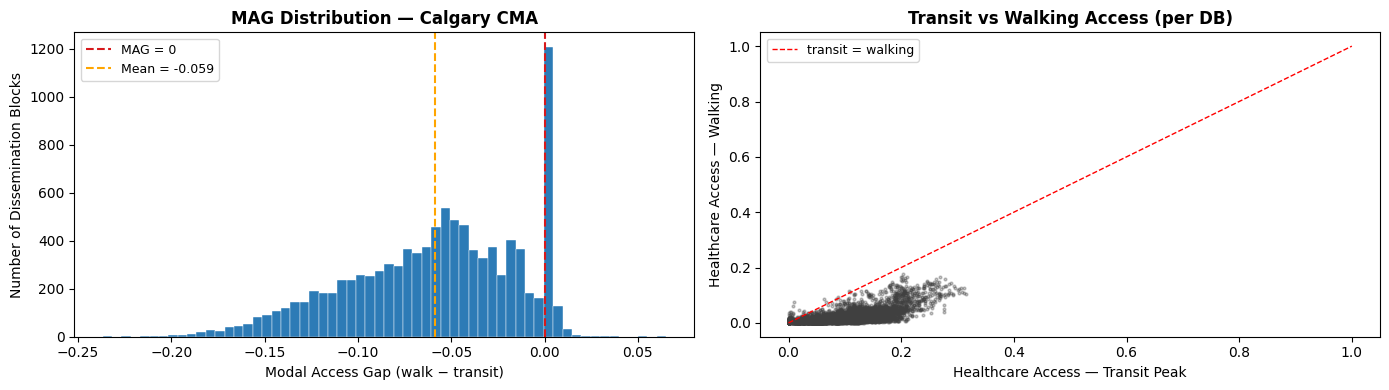

Saved: MAG_distribution_histogram.png


In [12]:

#Compute MAG (Modal Access Gap) as walking HF minus transit HF
# NaN propagates cleanly: if either mode score is suppressed, MAG = NaN
mag_df['MAG'] = mag_df['acs_idx_hf_walk'] - mag_df['acs_idx_hf_transit']
 
#Descriptive stats (on non-null rows only)
print('\nMAG descriptive statistics (non-null rows):')
print(mag_df['MAG'].describe().round(4))
 
n_valid = mag_df['MAG'].notna().sum()
print(f'\nDBs with valid MAG             : {n_valid:,}  ({100*n_valid/total:.1f}%)')
print(f'DBs where walking > transit (MAG > 0)  : {(mag_df["MAG"] > 0).sum():,}')
print(f'DBs where transit > walking (MAG < 0)  : {(mag_df["MAG"] < 0).sum():,}')
print(f'DBs where equal                        : {(mag_df["MAG"] == 0).sum():,}')
 
#Histogram
import matplotlib.pyplot as plt
import os
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
# Left: raw MAG distribution
axes[0].hist(mag_df['MAG'].dropna(), bins=60, color='#2c7bb6', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='#d7191c', linewidth=1.5, linestyle='--', label='MAG = 0')
axes[0].axvline(mag_df['MAG'].mean(), color='orange', linewidth=1.5,
                linestyle='--', label=f'Mean = {mag_df["MAG"].mean():.3f}')
axes[0].set_xlabel('Modal Access Gap (walk − transit)', fontsize=10)
axes[0].set_ylabel('Number of Dissemination Blocks', fontsize=10)
axes[0].set_title('MAG Distribution — Calgary CMA', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
 
# Right: transit vs walking scatter (spot check)
axes[1].scatter(
    mag_df['acs_idx_hf_transit'], mag_df['acs_idx_hf_walk'],
    alpha=0.3, s=4, color='#404040'
)
axes[1].plot([0,1],[0,1], 'r--', linewidth=1, label='transit = walking')
axes[1].set_xlabel('Healthcare Access — Transit Peak', fontsize=10)
axes[1].set_ylabel('Healthcare Access — Walking', fontsize=10)
axes[1].set_title('Transit vs Walking Access (per DB)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
 
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'MAG_distribution_histogram.png'), dpi=150)
plt.show()
print('Saved: MAG_distribution_histogram.png')
 

## 7. Load CIMD 2021

The CIMD has one row per DA. We will aggregate our DB-level MAG up to DA level, then join CIMD. The join key is DAUID.

In [15]:
#Find the CIMD file
# List what's in CIMD folder to confirm the filename
cimd_files = os.listdir(CIMD_DIR)
print('Files in CIMD directory:')
for f in cimd_files:
    print(f'  {f}')

Files in CIMD directory:
  can_scores_quintiles_EN.csv


In [16]:

CIMD_FILENAME = 'can_scores_quintiles_EN.csv'   # < update from above

cimd = pd.read_csv(
    os.path.join(CIMD_DIR, CIMD_FILENAME),
    dtype={'DAUID': str}   #keep as string
)

print(f'CIMD shape: {cimd.shape}')
print('\nCIMD columns:')
print(cimd.columns.tolist())
print('\nFirst 3 rows:')
cimd.head(3)

CIMD shape: (55726, 11)

CIMD columns:
['Dissemination Area (DA)', 'Province', 'DA Population', 'Residential instability Quintiles', 'Residential instability Scores', 'Ethno-cultural composition Quintiles', 'Ethno-cultural composition Scores', 'Economic dependency Quintiles', 'Economic dependency Scores', 'Situational vulnerability Quintiles', 'Situational vulnerability Scores']

First 3 rows:


,Dissemination Area (DA),Province,DA Population,Residential instability Quintiles,Residential instability Scores,Ethno-cultural composition Quintiles,Ethno-cultural composition Scores,Economic dependency Quintiles,Economic dependency Scores,Situational vulnerability Quintiles,Situational vulnerability Scores
0,10010165,Newfoundland & Labrador,500,4,0.028,2,-0.754,2,-0.427,2,-0.382
1,10010166,Newfoundland & Labrador,325,3,-0.065,4,0.107,4,0.312,2,-0.379
2,10010167,Newfoundland & Labrador,435,1,-0.840,1,-0.824,5,1.506,2,-0.487


In [17]:
# Identify the four deprivation dimension columns in the CIMD dataset.
# Print all columns containing keywords to confirm:
keywords = ['instab', 'depend', 'vuln', 'ethno', 'cultur', 'compos', 'quintile', 'score']
relevant = [c for c in cimd.columns if any(k.lower() in c.lower() for k in keywords)]
print('Likely CIMD dimension columns:')
for c in relevant:
    print(f'  {c}')

Likely CIMD dimension columns:
  Residential instability Quintiles
  Residential instability Scores
  Ethno-cultural composition Quintiles
  Ethno-cultural composition Scores
  Economic dependency Quintiles
  Economic dependency Scores
  Situational vulnerability Quintiles
  Situational vulnerability Scores


In [19]:
# Set the four dimension column names based on output above
# Use scores for ML; quintiles for mapping
#CIMD dimension column names (confirmed from file):

CIMD_DIMS = {
    'res_instability'  : 'Residential instability Scores',
    'econ_dependency'  : 'Economic dependency Scores',
    'situational_vuln' : 'Situational vulnerability Scores',
    'ethnocultural'    : 'Ethno-cultural composition Scores',
}

CIMD_QUINTS = {
    'res_instability_q'  : 'Residential instability Quintiles',
    'econ_dependency_q'  : 'Economic dependency Quintiles',
    'situational_vuln_q' : 'Situational vulnerability Quintiles',
    'ethnocultural_q'    : 'Ethno-cultural composition Quintiles',
}

# Verify all columns exist
all_cimd_cols = list(CIMD_DIMS.values()) + list(CIMD_QUINTS.values())
missing = [c for c in all_cimd_cols if c not in cimd.columns]
if missing:
    print(f'WARNING! missing columns: {missing}')
else:
    print('All 8 CIMD columns confirmed OK')
    for k, v in {**CIMD_DIMS, **CIMD_QUINTS}.items():
        print(f'  {k:<22} is {v}')

All 8 CIMD columns confirmed OK
  res_instability        is Residential instability Scores
  econ_dependency        is Economic dependency Scores
  situational_vuln       is Situational vulnerability Scores
  ethnocultural          is Ethno-cultural composition Scores
  res_instability_q      is Residential instability Quintiles
  econ_dependency_q      is Economic dependency Quintiles
  situational_vuln_q     is Situational vulnerability Quintiles
  ethnocultural_q        is Ethno-cultural composition Quintiles


## 8. Aggregate MAG from DB to DA Level, then Join CIMD

In [20]:
HF_COL = 'acs_idx_hf'
ID_COLS = ['DBUID', 'DAUID', 'CSDUID', 'CSDNAME', 'CMAUID', 'CMANAME', 'PRUID', 'PRCODE']

# Step 1: Merge transit and walking
mag_df = sam_transit_yyc[ID_COLS + [HF_COL]].merge(
    sam_walking_yyc[['DBUID', HF_COL]],
    on='DBUID',
    suffixes=('_transit', '_walk')
)

# Step 2: Force numeric (handle '..' suppression codes)
mag_df['acs_idx_hf_transit'] = pd.to_numeric(mag_df['acs_idx_hf_transit'], errors='coerce')
mag_df['acs_idx_hf_walk']    = pd.to_numeric(mag_df['acs_idx_hf_walk'],    errors='coerce')

# Step 3: Compute MAG
mag_df['MAG'] = mag_df['acs_idx_hf_walk'] - mag_df['acs_idx_hf_transit']

# Step 4: Flag transit-void blocks
mag_df['transit_void'] = mag_df['acs_idx_hf_transit'].isna()

# Step 5: Assign quartiles on valid rows only, merge back
mag_valid = mag_df[mag_df['MAG'].notna()].copy()
mag_valid['MAG_quartile_int'] = pd.qcut(mag_valid['MAG'], q=4, labels=[4,3,2,1]).astype(int)
mag_valid['MAG_quartile']     = pd.qcut(mag_valid['MAG'], q=4,
                                    labels=['Q4_most_disadvantaged','Q3','Q2','Q1_least_disadvantaged'])

mag_df = mag_df.merge(
    mag_valid[['DBUID','MAG_quartile','MAG_quartile_int']],
    on='DBUID', how='left'
)

#Confirm
print(f'Total DBs              : {len(mag_df):,}')
print(f'Valid MAG              : {mag_df["MAG"].notna().sum():,}')
print(f'Transit-void           : {mag_df["transit_void"].sum():,}')
print(f'MAG mean               : {mag_df["MAG"].mean():.4f}')
print(f'Columns                : {mag_df.columns.tolist()}')

Total DBs              : 11,251
Valid MAG              : 10,195
Transit-void           : 1,056
MAG mean               : -0.0589
Columns                : ['DBUID', 'DAUID', 'CSDUID', 'CSDNAME', 'CMAUID', 'CMANAME', 'PRUID', 'PRCODE', 'acs_idx_hf_transit', 'acs_idx_hf_walk', 'MAG', 'transit_void', 'MAG_quartile', 'MAG_quartile_int']


In [21]:
# Reconcile mag_df: ensure MAG column exists from the fix cells

# Check what columns we actually have
print('Columns in mag_df:', mag_df.columns.tolist())
print('Shape:', mag_df.shape)

# If MAG column is missing, recompute it now
if 'MAG' not in mag_df.columns:
    mag_df['MAG'] = mag_df['acs_idx_hf_walk'] - mag_df['acs_idx_hf_transit']
    print('MAG column recomputed')

# If MAG_quartile columns are missing, add them from mag_valid
if 'MAG_quartile' not in mag_df.columns:
    mag_df = mag_df.merge(
        mag_valid[['DBUID', 'MAG_quartile', 'MAG_quartile_int']],
        on='DBUID', how='left'
    )
    print('MAG quartile columns merged in')

#confirm
print('\nFinal mag_df columns:', mag_df.columns.tolist())
print('MAG null count:', mag_df['MAG'].isna().sum())
print('MAG sample values:', mag_df['MAG'].dropna().head(3).values)

Columns in mag_df: ['DBUID', 'DAUID', 'CSDUID', 'CSDNAME', 'CMAUID', 'CMANAME', 'PRUID', 'PRCODE', 'acs_idx_hf_transit', 'acs_idx_hf_walk', 'MAG', 'transit_void', 'MAG_quartile', 'MAG_quartile_int']
Shape: (11251, 14)

Final mag_df columns: ['DBUID', 'DAUID', 'CSDUID', 'CSDNAME', 'CMAUID', 'CMANAME', 'PRUID', 'PRCODE', 'acs_idx_hf_transit', 'acs_idx_hf_walk', 'MAG', 'transit_void', 'MAG_quartile', 'MAG_quartile_int']
MAG null count: 1056
MAG sample values: [-0.0468 -0.0412 -0.0473]


In [22]:
# Aggregate MAG to DA level
# For each DA: take the mean MAG of all its constituent DBs
# Also keep mean transit and walking scores separately for reference
mag_da = mag_df.groupby('DAUID').agg(
    MAG_mean              = ('MAG',                   'mean'),
    MAG_std               = ('MAG',                   'std'),
    hf_transit_mean       = ('acs_idx_hf_transit',    'mean'),
    hf_walk_mean          = ('acs_idx_hf_walk',       'mean'),
    n_blocks              = ('DBUID',                 'count'),
    CSDNAME               = ('CSDNAME',               'first'),
    CMANAME               = ('CMANAME',               'first'),
).reset_index()

print(f'DA-level MAG table: {mag_da.shape}')
mag_da.head(3)

DA-level MAG table: (1898, 8)


,DAUID,MAG_mean,MAG_std,hf_transit_mean,hf_walk_mean,n_blocks,CSDNAME,CMANAME
0,48060056,-0.045100,0.003387,0.048333,0.003233,3,Calgary,Calgary
1,48060057,-0.054167,0.004734,0.056833,0.002667,3,Calgary,Calgary
2,48060058,-0.050400,0.007637,0.053800,0.003400,2,Calgary,Calgary


In [23]:
print(cimd.columns.tolist())

['Dissemination Area (DA)', 'Province', 'DA Population', 'Residential instability Quintiles', 'Residential instability Scores', 'Ethno-cultural composition Quintiles', 'Ethno-cultural composition Scores', 'Economic dependency Quintiles', 'Economic dependency Scores', 'Situational vulnerability Quintiles', 'Situational vulnerability Scores']


In [24]:
# Rename DA identifier column to DAUID
cimd = cimd.rename(columns={'Dissemination Area (DA)': 'DAUID'})

# Force string type to match mag_df DAUID
cimd['DAUID'] = cimd['DAUID'].astype(str)

# Subset CIMD to Calgary DAs only
calgary_daids = set(mag_da['DAUID'].unique())
cimd_calgary = cimd[cimd['DAUID'].isin(calgary_daids)].copy()

print(f'CIMD rows for Calgary CMA: {cimd_calgary.shape[0]:,}')
print(f'Sample DAUID from CIMD   : {cimd_calgary["DAUID"].iloc[0]}')
print(f'Sample DAUID from mag_da : {mag_da["DAUID"].iloc[0]}')

CIMD rows for Calgary CMA: 1,878
Sample DAUID from CIMD   : 48060056
Sample DAUID from mag_da : 48060056


In [25]:
#Join MAG (DA level) to CIMD 
# Select only DAUID + dimension columns from CIMD to keep it clean
cimd_cols_to_keep = ['DAUID'] + list(CIMD_DIMS.values()) + list(CIMD_QUINTS.values())
# Remove placeholder values if still unfilled
cimd_cols_to_keep = [c for c in cimd_cols_to_keep if c != 'REPLACE_WITH_ACTUAL_COLUMN_NAME']

joined_da = mag_da.merge(
    cimd_calgary[cimd_cols_to_keep],
    on='DAUID',
    how='left'    # left join: keep all Calgary DAs even if CIMD has no match
)

print(f'Joined DA table shape: {joined_da.shape}')
print(f'DAs with CIMD match  : {joined_da[list(CIMD_DIMS.values())[0]].notna().sum():,}' 
      if list(CIMD_DIMS.values())[0] != 'REPLACE_WITH_ACTUAL_COLUMN_NAME' else 'Fill in CIMD_DIMS first')
joined_da.head(3)

Joined DA table shape: (1898, 16)
DAs with CIMD match  : 1,878


,DAUID,MAG_mean,MAG_std,hf_transit_mean,hf_walk_mean,n_blocks,CSDNAME,CMANAME,Residential instability Scores,Economic dependency Scores,Situational vulnerability Scores,Ethno-cultural composition Scores,Residential instability Quintiles,Economic dependency Quintiles,Situational vulnerability Quintiles,Ethno-cultural composition Quintiles
0,48060056,-0.045100,0.003387,0.048333,0.003233,3,Calgary,Calgary,-0.958,-0.601,-0.076,0.729,1.0,2.0,3.0,4.0
1,48060057,-0.054167,0.004734,0.056833,0.002667,3,Calgary,Calgary,-0.610,-0.118,-0.008,0.927,2.0,3.0,4.0,5.0
2,48060058,-0.050400,0.007637,0.053800,0.003400,2,Calgary,Calgary,-0.696,0.286,-0.661,0.861,2.0,4.0,1.0,5.0


## 9. Load Boundary Shapefiles & Clip to Calgary

Load both DB (no DA for now) shapefiles. The national DB shapefile is large so clip it to Calgary's bounding box immediately after loading.

In [26]:
# shapefile paths 
def find_shp(directory):
    """Find the .shp file in a directory (recursive)."""
    for root, dirs, files in os.walk(directory):
        for f in files:
            if f.endswith('.shp'):
                return os.path.join(root, f)
    return None

db_shp_path = find_shp(DB_SHP_DIR)
#da_shp_path = find_shp(DA_SHP_DIR)

print(f'DB shapefile: {db_shp_path}')
#print(f'DA shapefile: {da_shp_path}')

DB shapefile: E:\phD work\Clgary project\MGAP\data\raw\DB_boundaries\ldb_000b21a_e.shp


In [27]:
# Calgary bounding box (WGS84)
#CALGARY_BBOX = (-114.8, 50.6, -113.5, 51.6)   # (minx, miny, maxx, maxy)

# Derive DA geometry by dissolving DB shapefile
# No separate DA shapefile so dissolve DB polygons up to DA level

#print('Loading DB shapefile (clipped to Calgary bbox)...')

#db_gdf = gpd.read_file(db_shp_path, bbox=CALGARY_BBOX)
# Load full DB shapefile then filter by DBUID 
# (bbox clip failed because shapefile CRS is not WGS84)
# Instead, load full file, filter to Calgary DBs known from SAM

print('Loading DB shapefile, full national...')
db_gdf = gpd.read_file(db_shp_path)
print(f'  National DB count: {len(db_gdf):,}')
print(f'  CRS: {db_gdf.crs}')

# Standardise DBUID column name
db_uid_col = [c for c in db_gdf.columns if 'dbuid' in c.lower()]
print(f'  DBUID column in shapefile: {db_uid_col}')
if db_uid_col and db_uid_col[0] != 'DBUID':
    db_gdf = db_gdf.rename(columns={db_uid_col[0]: 'DBUID'})

db_gdf['DBUID'] = db_gdf['DBUID'].astype(str)

# Filter to Calgary DBs using the DBUID list from SAM data
calgary_dbids = set(mag_df['DBUID'].unique())
db_gdf = db_gdf[db_gdf['DBUID'].isin(calgary_dbids)].copy()
print(f'  Calgary DB count: {len(db_gdf):,}')

# ── Derive DA-level geometry by dissolving ────────────────────────────────────
print('\nDeriving DA boundaries by dissolving DB polygons...')
db_gdf['DAUID'] = db_gdf['DBUID'].str[:8]
da_gdf = db_gdf[['DAUID','geometry']].dissolve(by='DAUID').reset_index()
print(f'  Calgary DA count: {len(da_gdf):,}')
print(f'  Calgary DB count: {len(db_gdf):,}')

# Standardise DBUID column name
db_uid_col = [c for c in db_gdf.columns if 'dbuid' in c.lower()]
print(f'  DBUID column in shapefile: {db_uid_col}')
if db_uid_col and db_uid_col[0] != 'DBUID':
    db_gdf = db_gdf.rename(columns={db_uid_col[0]: 'DBUID'})

# Force string type
db_gdf['DBUID'] = db_gdf['DBUID'].astype(str)


Loading DB shapefile, full national...
  National DB count: 498,547
  CRS: EPSG:3347
  DBUID column in shapefile: ['DBUID']
  Calgary DB count: 11,251

Deriving DA boundaries by dissolving DB polygons...
  Calgary DA count: 1,898
  Calgary DB count: 11,251
  DBUID column in shapefile: ['DBUID']


In [28]:
print('Reloading DB shapefile (full national)...')
db_gdf = gpd.read_file(db_shp_path)
db_gdf = db_gdf.rename(columns={'DBUID': 'DBUID'})  # already correct
db_gdf['DBUID'] = db_gdf['DBUID'].astype(str).str.strip()

calgary_dbids = set(mag_df['DBUID'].unique())
db_gdf = db_gdf[db_gdf['DBUID'].isin(calgary_dbids)].copy()
db_gdf['DAUID'] = db_gdf['DBUID'].str[:8]

da_gdf = db_gdf[['DAUID','geometry']].dissolve(by='DAUID').reset_index()

print(f'Calgary DB count : {len(db_gdf):,}')
print(f'Calgary DA count : {len(da_gdf):,}')
print(f'DBUID sample     : {db_gdf["DBUID"].head(3).tolist()}')

Reloading DB shapefile (full national)...
Calgary DB count : 11,251
Calgary DA count : 1,898
DBUID sample     : ['48060056001', '48060056002', '48060056003']


In [29]:
print('DB shapefile DBUID sample:')
print(db_gdf['DBUID'].head(3).tolist())
print('dtype:', db_gdf['DBUID'].dtype)

print('\nmag_df DBUID sample:')
print(mag_df['DBUID'].head(3).tolist())
print('dtype:', mag_df['DBUID'].dtype)

print('\nLength check:')
print('shapefile DBUID length:', db_gdf['DBUID'].str.len().value_counts().head())
print('mag_df DBUID length:', mag_df['DBUID'].str.len().value_counts().head())

DB shapefile DBUID sample:
['48060056001', '48060056002', '48060056003']
dtype: str

mag_df DBUID sample:
['48060056001', '48060056002', '48060056003']
dtype: str

Length check:
shapefile DBUID length: DBUID
11    11251
Name: count, dtype: int64
mag_df DBUID length: DBUID
11    11251
Name: count, dtype: int64


## 10. Spatial Join: Attach MAG to Geometries

In [30]:
# DB-level GeoDataFrame: join DB shapefile to DB-level MAG 
db_mag_gdf = db_gdf.merge(
    mag_df[['DBUID', 'DAUID', 'MAG', 'MAG_quartile', 'MAG_quartile_int',
            'acs_idx_hf_transit', 'acs_idx_hf_walk', 'CSDNAME']],
    on='DBUID',
    how='inner'
)
print(f'DB-level GeoDataFrame: {len(db_mag_gdf):,} rows')

#DA-level GeoDataFrame: join DA shapefile to DA-level joined table
da_mag_gdf = da_gdf.merge(
    joined_da,
    on='DAUID',
    how='inner'
)
print(f'DA-level GeoDataFrame: {len(da_mag_gdf):,} rows')

DB-level GeoDataFrame: 11,251 rows
DA-level GeoDataFrame: 1,898 rows


In [31]:
#  Reproject to projected CRS for area calculations later
# UTM Zone 12N (EPSG:32612) for Calgary
TARGET_CRS = 'EPSG:32612'

db_mag_gdf = db_mag_gdf.to_crs(TARGET_CRS)
da_mag_gdf = da_mag_gdf.to_crs(TARGET_CRS)

# Add area in km² (for ML)
db_mag_gdf['area_km2'] = db_mag_gdf.geometry.area / 1e6
da_mag_gdf['area_km2'] = da_mag_gdf.geometry.area / 1e6

print('Reprojected to UTM Zone 12N (EPSG:32612)')
print(f'DB area range: {db_mag_gdf["area_km2"].min():.4f} – {db_mag_gdf["area_km2"].max():.2f} km²')
print(f'DA area range: {da_mag_gdf["area_km2"].min():.4f} – {da_mag_gdf["area_km2"].max():.2f} km²')

Reprojected to UTM Zone 12N (EPSG:32612)
DB area range: 0.0001 – 193.35 km²
DA area range: 0.0173 – 366.13 km²


## 11. Visual Check: MAG Map (Rough)

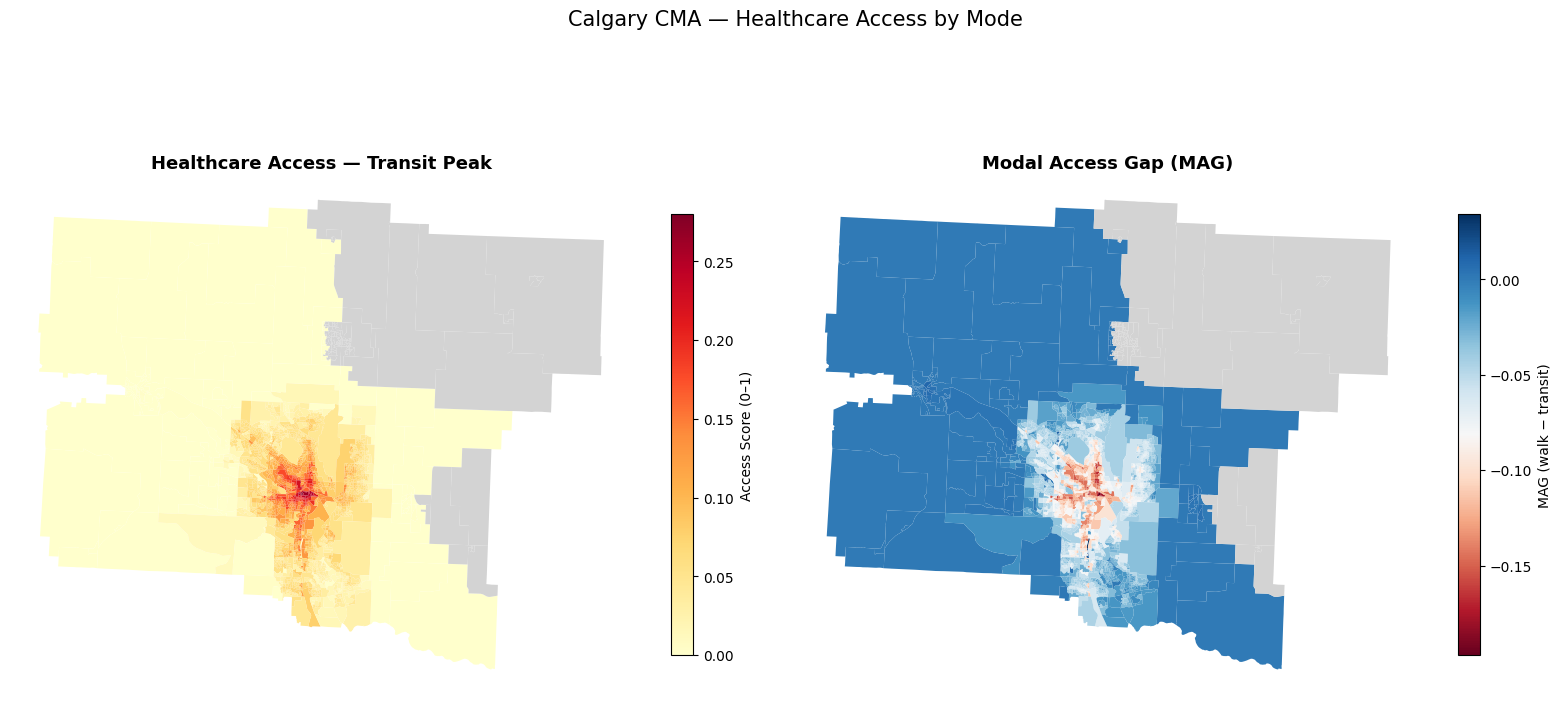

Saved: NB1_quick_map_check.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: transit healthcare access
da_mag_gdf.plot(
    column='hf_transit_mean', ax=axes[0],
    cmap='YlOrRd', legend=True,
    legend_kwds={'label': 'Access Score (0–1)', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey'}
)
axes[0].set_title('Healthcare Access — Transit Peak', fontsize=13, fontweight='bold')
axes[0].axis('off')

# Right: Modal Access Gap
da_mag_gdf.plot(
    column='MAG_mean', ax=axes[1],
    cmap='RdBu',   # red = walking much worse than transit, blue = walking better
    legend=True,
    legend_kwds={'label': 'MAG (walk − transit)', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey'}
)
axes[1].set_title('Modal Access Gap (MAG)', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Calgary CMA — Healthcare Access by Mode', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'NB1_quick_map_check.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: NB1_quick_map_check.png')

## 12. Export Processed Data

Save the cleaned GeoDataFrames to disk.

In [34]:
# Save DB-level GeoDataFrame as GeoPackage (not just shapefile) 
db_out = os.path.join(PROCESSED_DIR, 'calgary_DB_MAG.gpkg')
db_mag_gdf.to_file(db_out, driver='GPKG')
print(f'Saved DB GeoPackage: {db_out}')

# Save DA-level GeoDataFrame 
da_out = os.path.join(PROCESSED_DIR, 'calgary_DA_MAG_CIMD.gpkg')
da_mag_gdf.to_file(da_out, driver='GPKG')
print(f'Saved DA GeoPackage: {da_out}')

# Also save flat CSV of DA table (for ML notebook, no geometry needed)
csv_out = os.path.join(PROCESSED_DIR, 'calgary_DA_MAG_CIMD.csv')
joined_da.to_csv(csv_out, index=False)
print(f'Saved DA CSV: {csv_out}')

print('\n Notebook 1 Summary:')
print(f'  DB-level blocks : {len(db_mag_gdf):,}')
print(f'  DA-level areas  : {len(da_mag_gdf):,}')
print(f'  MAG range       : {db_mag_gdf["MAG"].min():.4f}  to  {db_mag_gdf["MAG"].max():.4f}')
print(f'  MAG mean        : {db_mag_gdf["MAG"].mean():.4f}')

Saved DB GeoPackage: E:\phD work\Clgary project\MGAP\data\processed\calgary_DB_MAG.gpkg
Saved DA GeoPackage: E:\phD work\Clgary project\MGAP\data\processed\calgary_DA_MAG_CIMD.gpkg
Saved DA CSV: E:\phD work\Clgary project\MGAP\data\processed\calgary_DA_MAG_CIMD.csv

 Notebook 1 Summary:
  DB-level blocks : 11,251
  DA-level areas  : 1,898
  MAG range       : -0.2368  to  0.0650
  MAG mean        : -0.0589
